# Model 2 — Position / Exposure Risk Model

## 1. Data preparation
- Source tables: Position, Market
- Columns used:
  - Position: user_id, market_id, yes_tokens, no_tokens, total_staked, created_at, updated_at
  - Market: id, title, status, liquidity_pool, fee_percentage (optional)
- Filtering rules:
  - Only OPEN or RESOLVED markets
  - Positions with total_staked > 0

## 2. Feature list (heuristic / rule-based model)
- user_market_exposure:
  - yes_tokens, no_tokens, total_staked
  - net_tokens = yes_tokens - no_tokens
  - direction = sign(net_tokens)
- market_risk_kpis:
  - open_interest = Σ total_staked per market
  - num_traders = unique users per market
  - top1_share, top5_share, HHI based on per-user total_staked share

## 3. Performance metrics (for this heuristic model)
- Distribution of open_interest across markets
- Distribution of top1_share (market concentration)
- Distribution of user_max_share (user-level concentration)
- Baseline statistics (mean, median, 95th percentile)

## 4. Significance / confidence intervals (simple bootstrap)
- Bootstrap over markets:
  - Estimate CI for mean(open_interest)
  - Estimate CI for mean(top1_share)

## 5. Decision impact
- High-concentration markets (top1_share > 0.5) → "HIGH RISK MARKET"
- Users with max_market_share > 0.5 → "HIGH RISK USER"
- Output: risk flags that can be used by dashboards / alerts.

## 6. Relation to A/B/MAB logic
- These exposure features will later be used:
  - as context for the Recommender model
  - as input to the Multi-Armed Bandit (traffic allocation per market/risk segment)


In [7]:
import pandas as pd
import numpy as np

pd.set_option("display.max_rows", 10)
pd.set_option("display.max_columns", 50)


In [ ]:
positions_path = r"C:\Users\orxan\OneDrive\Masaüstü\prediction_hub\PredictBack\predicthub_backend\ml\data\synthetic\positions.csv"
markets_path = r"C:\Users\orxan\OneDrive\Masaüstü\prediction_hub\PredictBack\predicthub_backend\ml\data\synthetic\markets.csv"

df_pos = pd.read_csv(positions_path)
df_markets = pd.read_csv(markets_path)


df_markets.head()


,id,title,description,category_id,status,resolution_outcome,liquidity_pool,fee_percentage,onchain_market_id,onchain_tx_hash,created_by,created_at,ends_at
0,44,Synthetic Market 29,Synthetic market for ML testing,5,active,NaN,5236.21,0.02,NaN,synthetic_market_29,57,2025-11-30T09:03:51.028781+00:00,2025-12-28T09:03:51.028482+00:00
1,43,Synthetic Market 28,Synthetic market for ML testing,5,active,NaN,8849.50,0.02,NaN,synthetic_market_28,57,2025-11-30T09:03:51.026152+00:00,2025-12-13T09:03:51.025991+00:00
2,42,Synthetic Market 27,Synthetic market for ML testing,5,active,NaN,7311.50,0.02,NaN,synthetic_market_27,57,2025-11-30T09:03:51.024377+00:00,2025-12-26T09:03:51.024147+00:00
3,41,Synthetic Market 26,Synthetic market for ML testing,5,active,NaN,3401.25,0.02,NaN,synthetic_market_26,57,2025-11-30T09:03:51.022876+00:00,2025-12-08T09:03:51.022691+00:00
4,40,Synthetic Market 25,Synthetic market for ML testing,5,active,NaN,7615.52,0.02,NaN,synthetic_market_25,57,2025-11-30T09:03:51.019957+00:00,2025-12-28T09:03:51.019568+00:00


In [4]:
df_pos.head()

,id,user_id,market_id,yes_tokens,no_tokens,total_staked,created_at,updated_at
0,5,57,26,0.00,0.00,42.62,2025-11-30T09:04:27.127333+00:00,2025-11-30T09:04:27.127373+00:00
1,6,57,17,21.35,0.00,44.76,2025-11-30T09:04:27.133285+00:00,2025-11-30T09:04:27.133296+00:00
2,7,57,18,0.00,42.47,29.45,2025-11-30T09:04:27.135763+00:00,2025-11-30T09:04:27.135773+00:00
3,8,57,16,0.00,42.53,26.48,2025-11-30T09:04:27.138484+00:00,2025-11-30T09:04:27.138494+00:00
4,9,57,38,26.36,0.00,37.04,2025-11-30T09:04:27.141084+00:00,2025-11-30T09:04:27.141092+00:00


In [5]:
df_pos.info()
df_pos.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6875 entries, 0 to 6874
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            6875 non-null   int64  
 1   user_id       6875 non-null   int64  
 2   market_id     6875 non-null   int64  
 3   yes_tokens    6875 non-null   float64
 4   no_tokens     6875 non-null   float64
 5   total_staked  6875 non-null   float64
 6   created_at    6875 non-null   object 
 7   updated_at    6875 non-null   object 
dtypes: float64(3), int64(3), object(2)
memory usage: 429.8+ KB


,id,user_id,market_id,yes_tokens,no_tokens,total_staked
count,6875.000000,6875.000000,6875.000000,6875.000000,6875.000000,6875.000000
mean,3442.000000,308.122036,29.505891,52.919913,46.407495,100.826819
std,1984.785883,143.910685,8.620507,175.567022,161.948977,174.701230
min,5.000000,57.000000,15.000000,0.000000,0.000000,1.030000
25%,1723.500000,186.000000,22.000000,0.000000,0.000000,21.395000
50%,3442.000000,307.000000,30.000000,0.000000,0.000000,39.110000
75%,5160.500000,433.000000,37.000000,26.785000,23.650000,69.790000
max,6879.000000,556.000000,44.000000,2018.170000,2282.340000,1719.680000


In [6]:
df_markets.info()
df_markets.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  30 non-null     int64  
 1   title               30 non-null     object 
 2   description         30 non-null     object 
 3   category_id         30 non-null     int64  
 4   status              30 non-null     object 
 5   resolution_outcome  0 non-null      float64
 6   liquidity_pool      30 non-null     float64
 7   fee_percentage      30 non-null     float64
 8   onchain_market_id   0 non-null      float64
 9   onchain_tx_hash     30 non-null     object 
 10  created_by          30 non-null     int64  
 11  created_at          30 non-null     object 
 12  ends_at             30 non-null     object 
dtypes: float64(4), int64(3), object(6)
memory usage: 3.2+ KB


,id,category_id,resolution_outcome,liquidity_pool,fee_percentage,onchain_market_id,created_by
count,30.000000,30.0,0.0,30.000000,3.000000e+01,0.0,30.0
mean,29.500000,5.0,NaN,5868.794667,2.000000e-02,NaN,57.0
std,8.803408,0.0,NaN,2644.087161,3.528758e-18,NaN,0.0
min,15.000000,5.0,NaN,1376.460000,2.000000e-02,NaN,57.0
25%,22.250000,5.0,NaN,3631.672500,2.000000e-02,NaN,57.0
50%,29.500000,5.0,NaN,6043.555000,2.000000e-02,NaN,57.0
75%,36.750000,5.0,NaN,7967.435000,2.000000e-02,NaN,57.0
max,44.000000,5.0,NaN,9749.770000,2.000000e-02,NaN,57.0


,id,user_id,market_id,yes_tokens,no_tokens,total_staked,created_at,updated_at,net_tokens,direction
0,5,57,26,0.00,0.00,42.62,2025-11-30T09:04:27.127333+00:00,2025-11-30T09:04:27.127373+00:00,0.00,0
1,6,57,17,21.35,0.00,44.76,2025-11-30T09:04:27.133285+00:00,2025-11-30T09:04:27.133296+00:00,21.35,1
2,7,57,18,0.00,42.47,29.45,2025-11-30T09:04:27.135763+00:00,2025-11-30T09:04:27.135773+00:00,-42.47,-1
3,8,57,16,0.00,42.53,26.48,2025-11-30T09:04:27.138484+00:00,2025-11-30T09:04:27.138494+00:00,-42.53,-1
4,9,57,38,26.36,0.00,37.04,2025-11-30T09:04:27.141084+00:00,2025-11-30T09:04:27.141092+00:00,26.36,1


In [9]:
df = df_pos.copy()

# Fill NaN values with 0 to avoid calculation issues
for col in ["yes_tokens", "no_tokens", "total_staked"]:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Net exposure: YES - NO (by token count)
df["net_tokens"] = df["yes_tokens"] - df["no_tokens"]

# Direction flag: 1 = more YES, -1 = more NO, 0 = balanced
df["direction"] = 0
df.loc[df["net_tokens"] > 0, "direction"] = 1
df.loc[df["net_tokens"] < 0, "direction"] = -1

df.head()

,id,user_id,market_id,yes_tokens,no_tokens,total_staked,created_at,updated_at,net_tokens,direction
0,5,57,26,0.00,0.00,42.62,2025-11-30T09:04:27.127333+00:00,2025-11-30T09:04:27.127373+00:00,0.00,0
1,6,57,17,21.35,0.00,44.76,2025-11-30T09:04:27.133285+00:00,2025-11-30T09:04:27.133296+00:00,21.35,1
2,7,57,18,0.00,42.47,29.45,2025-11-30T09:04:27.135763+00:00,2025-11-30T09:04:27.135773+00:00,-42.47,-1
3,8,57,16,0.00,42.53,26.48,2025-11-30T09:04:27.138484+00:00,2025-11-30T09:04:27.138494+00:00,-42.53,-1
4,9,57,38,26.36,0.00,37.04,2025-11-30T09:04:27.141084+00:00,2025-11-30T09:04:27.141092+00:00,26.36,1


In [10]:
market_open_interest = (
    df.groupby("market_id", as_index=False)
      .agg(
          open_interest=("total_staked", "sum"),
          num_traders=("user_id", "nunique"),
      )
)

market_open_interest.head()


,market_id,open_interest,num_traders
0,15,21226.02,217
1,16,22589.49,224
2,17,27096.72,238
3,18,23805.73,223
4,19,25645.44,242


In [16]:
market_user_exposure = df[["market_id", "user_id", "total_staked"]].copy()

# Total per market
total_by_market = (
    market_user_exposure.groupby("market_id", as_index=False)
    .agg(market_total=("total_staked", "sum"))
)

# Merge
market_user_exposure = market_user_exposure.merge(
    total_by_market,
    on="market_id",
    how="left",
)

# Each user's share in that market
market_user_exposure["share"] = (
    market_user_exposure["total_staked"] / market_user_exposure["market_total"]
)

market_user_exposure.head()

,market_id,user_id,total_staked,market_total,share
0,26,57,42.62,22402.44,0.001902
1,17,57,44.76,27096.72,0.001652
2,18,57,29.45,23805.73,0.001237
3,16,57,26.48,22589.49,0.001172
4,38,57,37.04,23299.55,0.001590


In [17]:
def concentration_stats(group, top_k=5):
    shares = group["share"].sort_values(ascending=False).values

    top1 = shares[0] if len(shares) > 0 else 0.0
    topk = shares[:top_k].sum() if len(shares) > 0 else 0.0

    # Herfindahl-Hirschman Index (HHI)
    hhi = np.sum(shares ** 2) if len(shares) > 0 else 0.0

    return pd.Series({
        "top1_share": top1,
        f"top{top_k}_share": topk,
        "hhi": hhi,
    })

market_concentration = (
    market_user_exposure
    .groupby("market_id")
    .apply(concentration_stats, top_k=5, include_groups=False)
    .reset_index()
)

market_concentration.head()

,market_id,top1_share,top5_share,hhi
0,15,0.044872,0.183563,0.016767
1,16,0.053390,0.182606,0.016891
2,17,0.057374,0.223733,0.019913
3,18,0.072238,0.223383,0.021434
4,19,0.050007,0.187200,0.016388


In [ ]:
# User total stake across all markets
user_total_stake = (
    df.groupby("user_id", as_index=False)
      .agg(
          total_stake_all_markets=("total_staked", "sum"),
          num_markets=("market_id", "nunique"),
      )
)

# Hər user + market üçün share ( artıq market_user_exposure-da var)
# Buradan user üçün "max_market_share" çıxara bilərik
user_max_share = (
    market_user_exposure.groupby("user_id", as_index=False)
    .agg(max_market_share=("share", "max"))
)

user_risk_profile = user_total_stake.merge(
    user_max_share,
    on="user_id",
    how="left",
)

user_risk_profile.head()


,user_id,total_stake_all_markets,num_markets,max_market_share
0,57,447.02,14,0.002410
1,58,687.90,19,0.004267
2,59,581.92,16,0.005525
3,61,758.22,16,0.003655
4,62,6628.94,16,0.038135


In [20]:
# User total stake across all markets
user_total_stake = (
    df.groupby("user_id", as_index=False)
      .agg(
          total_stake_all_markets=("total_staked", "sum"),
          num_markets=("market_id", "nunique"),
      )
)

# Max share per user across all their markets
user_max_share = (
    market_user_exposure.groupby("user_id", as_index=False)
    .agg(max_market_share=("share", "max"))
)

user_risk_profile = user_total_stake.merge(
    user_max_share,
    on="user_id",
    how="left",
)

user_risk_profile.head()

,user_id,total_stake_all_markets,num_markets,max_market_share
0,57,447.02,14,0.002410
1,58,687.90,19,0.004267
2,59,581.92,16,0.005525
3,61,758.22,16,0.003655
4,62,6628.94,16,0.038135


In [24]:
market_risk_kpis = market_open_interest.merge(
    market_concentration,
    on="market_id",
    how="left",
)


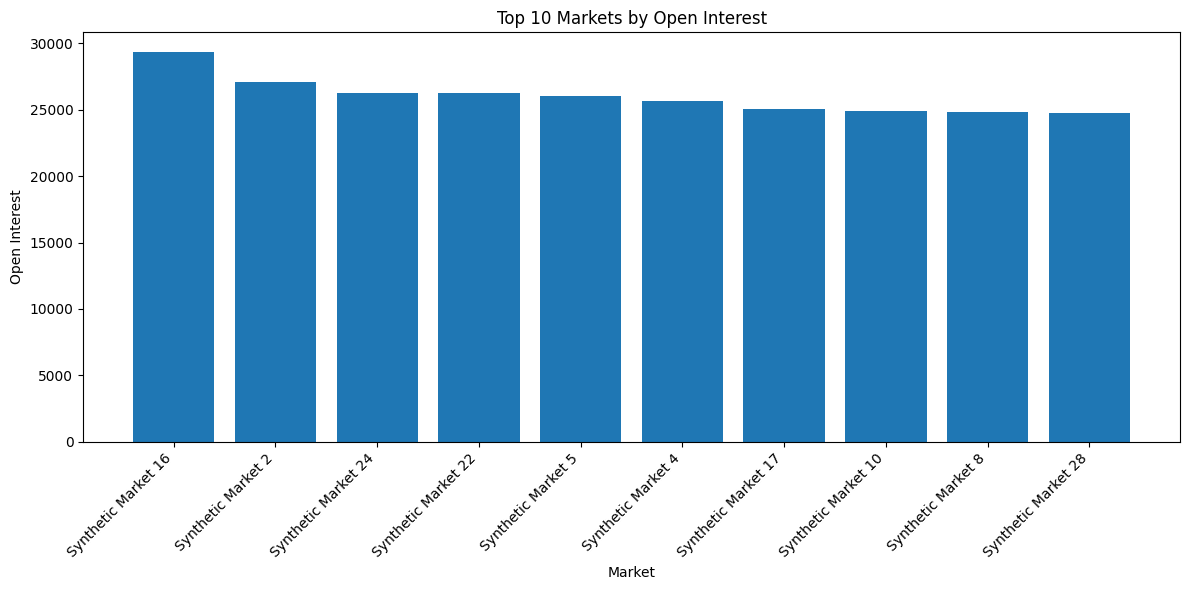

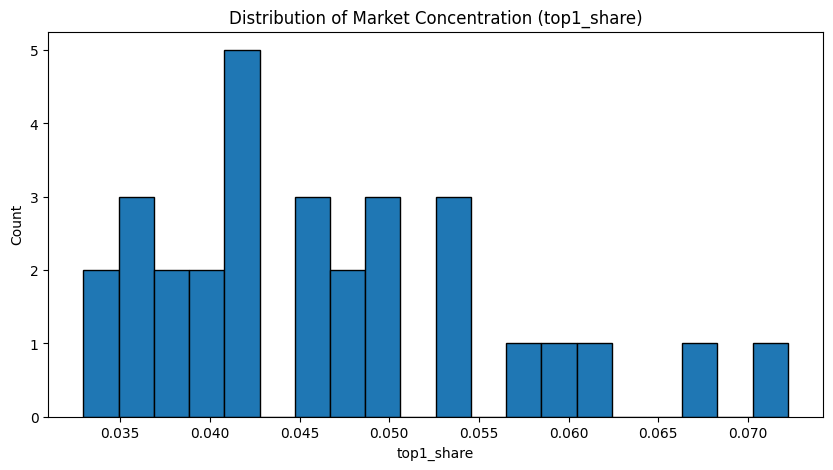

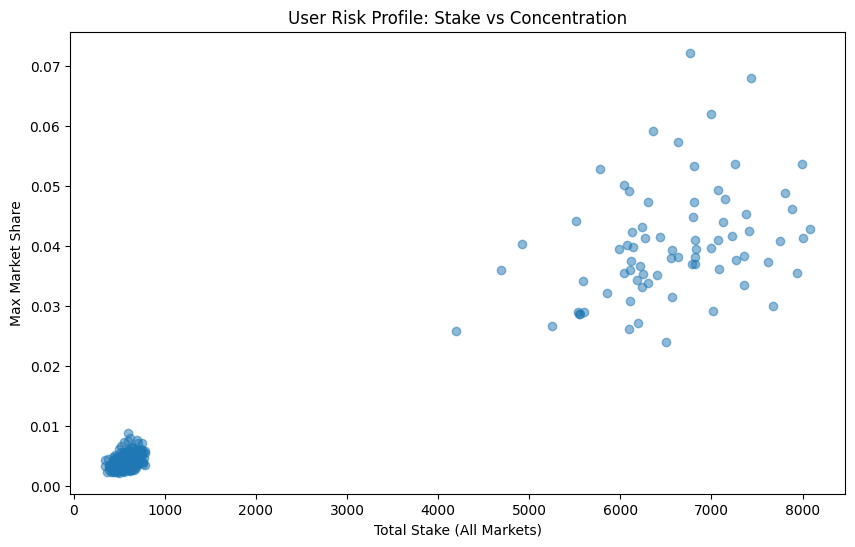

In [31]:
import matplotlib.pyplot as plt

# Merge to get market titles
market_risk_kpis_with_title = market_risk_kpis.merge(
    df_markets[["id", "title"]], 
    left_on="market_id", 
    right_on="id", 
    how="left"
)

# 1) Top 10 markets by open interest
top_markets = market_risk_kpis_with_title.sort_values("open_interest", ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_markets["title"], top_markets["open_interest"])
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Markets by Open Interest")
plt.xlabel("Market")
plt.ylabel("Open Interest")
plt.tight_layout()
plt.show()

# 2) Histogram of market concentration
plt.figure(figsize=(10, 5))
plt.hist(market_risk_kpis["top1_share"], bins=20, edgecolor='black')
plt.title("Distribution of Market Concentration (top1_share)")
plt.xlabel("top1_share")
plt.ylabel("Count")
plt.show()

# 3) User risk profile scatter
plt.figure(figsize=(10, 6))
plt.scatter(user_risk_profile["total_stake_all_markets"], user_risk_profile["max_market_share"], alpha=0.5)
plt.title("User Risk Profile: Stake vs Concentration")
plt.xlabel("Total Stake (All Markets)")
plt.ylabel("Max Market Share")
plt.show()